# Utterance emotion classification: a linear model beats both baselines, rare emotions stay hard

日本語要約: VoC（顧客の声）分析の第一段として、会話の各発話に 7 種の感情ラベルを
付ける分類器を作る。DailyDialog の 83% が「感情なし」という強い不均衡をまず可視化し、
多数派予測とキーワード辞書という 2 つのベースラインに対して、TF-IDF + ロジスティック
回帰がマクロ F1 で明確に勝つことを assert で確認する。ただし fear や disgust のような
希少クラスの F1 は低く、その事実を隠さずクラス別に示す。

**What this notebook shows**

- The DailyDialog emotion labels are heavily imbalanced: about 83 percent of
  utterances carry `no_emotion`, and three of the six emotions have under
  two percent support each.
- A dialogue-level train/test split, because utterances within one
  conversation are dependent and splitting them across sets would leak.
- Two honest baselines (majority class, keyword lexicon) and a TF-IDF plus
  logistic regression model, compared on macro-F1 with per-class detail.
- Asserted, not eyeballed: the model beats both baselines on macro-F1.
- Where the model fails: rare classes, and an accuracy that is lower than
  the majority baseline by construction of the balanced class weights.

This is the measurement layer for the trajectory analysis in notebooks 02
and 03. A per-utterance classifier is a commodity; what matters here is
knowing exactly how good (and how bad) it is before feeding its output
into conversation-level time series.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from voc_arc.classifier import (
    LexiconBaseline,
    MajorityBaseline,
    build_model,
    evaluate,
    per_class_f1,
)
from voc_arc.data import EMOTIONS, load_dataset, split_dialogues
from voc_arc.plotting import PALETTE, plot_class_distribution, set_style

set_style()
SEED = 42
CI = bool(os.environ.get("CI"))

## 1. Data

`load_dataset` uses the full corpus when `scripts/download_data.py` has
been run, and otherwise falls back to the committed 1,000-dialogue sample
under `data/sample/` (this is how the notebook runs in CI, where nothing
is downloaded). The committed version of this notebook was executed on the
full corpus.

In [2]:
df, source = load_dataset()
n_dialogues = df["dialogue_id"].nunique()
print(f"source={source}: {n_dialogues} dialogues, {len(df)} utterances")
df.head(8)

source=raw: 13117 dialogues, 102968 utterances


,dialogue_id,turn,text,emotion,emotion_name
0,0,0,The kitchen stinks .,2,disgust
1,0,1,I'll throw out the garbage .,0,no_emotion
2,1,0,"So Dick , how about getting some coffee for to...",4,happiness
3,1,1,Coffee ? I don ’ t honestly like that kind of ...,2,disgust
4,1,2,"Come on , you can at least try a little , besi...",0,no_emotion
5,1,3,What ’ s wrong with that ? Cigarette is the th...,1,anger
6,1,4,"Not for me , Dick .",0,no_emotion
7,2,0,Are things still going badly with your housegu...,0,no_emotion


## 2. The class imbalance is the first fact about this problem

Any accuracy number on this corpus is dominated by `no_emotion`. A model
that never predicts an emotion at all is right about 83 percent of the
time, which is why everything below is evaluated on macro-F1 (the
unweighted mean of per-class F1), where that degenerate strategy scores
close to zero on the six emotion classes.

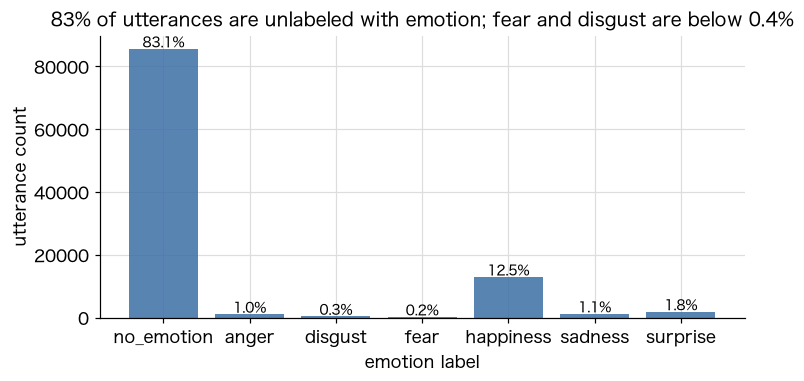

In [3]:
counts = df["emotion_name"].value_counts().reindex(EMOTIONS)
plot_class_distribution(
    counts,
    title="83% of utterances are unlabeled with emotion; fear and disgust are below 0.4%",
)
plt.tight_layout()

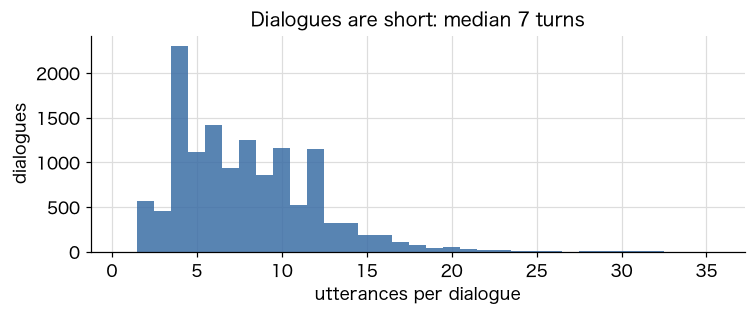

In [4]:
turns_per_dialogue = df.groupby("dialogue_id").size()
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(turns_per_dialogue, bins=np.arange(0.5, 36.5, 1.0), color=PALETTE[0], alpha=0.85)
ax.set_xlabel("utterances per dialogue")
ax.set_ylabel("dialogues")
ax.set_title(f"Dialogues are short: median {int(turns_per_dialogue.median())} turns")
plt.tight_layout()

## 3. Dialogue-level split

The split assigns whole conversations to train or test. An utterance-level
split would place turn 3 of a dialogue in train and turn 4 in test;
adjacent turns share topic words and speaker style, so the test score
would be inflated by leaked conversational context rather than measuring
generalization to unseen conversations.

In [5]:
train, test = split_dialogues(df, test_size=0.2, seed=SEED)
assert set(train["dialogue_id"]).isdisjoint(set(test["dialogue_id"]))
print(
    f"train: {train['dialogue_id'].nunique()} dialogues / {len(train)} utterances, "
    f"test: {test['dialogue_id'].nunique()} dialogues / {len(test)} utterances"
)

train: 10494 dialogues / 82560 utterances, test: 2623 dialogues / 20408 utterances


## 4. Baselines and model

- **Majority**: always predicts `no_emotion`. The floor.
- **Lexicon**: a small keyword list per emotion, first match wins. This is
  what a rule-based VoC dashboard effectively does, so beating it is the
  minimum bar for claiming that a trained model adds value.
- **Model**: TF-IDF (word 1-2 grams plus character 3-5 grams) into
  multinomial logistic regression with balanced class weights. No
  transformers on purpose: this trains in seconds on a laptop, the learned
  weights are inspectable, and it sets a reproducible reference point.

In [6]:
train_texts, train_y = train["text"].tolist(), train["emotion"].to_numpy()
test_texts, test_y = test["text"].tolist(), test["emotion"].to_numpy()

majority = MajorityBaseline().fit(train_texts, train_y)
lexicon = LexiconBaseline().fit(train_texts, train_y)
model = build_model(seed=SEED).fit(train_texts, train_y)

predictions = {
    "majority": majority.predict(test_texts),
    "lexicon": lexicon.predict(test_texts),
    "tfidf_logreg": model.predict(test_texts),
}
results = pd.DataFrame({name: evaluate(test_y, pred) for name, pred in predictions.items()}).T
results.round(3)

,macro_f1,weighted_f1,accuracy
majority,0.129,0.750,0.828
lexicon,0.286,0.801,0.809
tfidf_logreg,0.390,0.796,0.770


## 5. Numeric validation

The claim of this notebook is a ranking, so the ranking is asserted. If a
refactor or a data change breaks it, the notebook fails instead of
silently publishing a stale conclusion.

In [7]:
model_f1 = results.loc["tfidf_logreg", "macro_f1"]
assert model_f1 > results.loc["majority", "macro_f1"], "model must beat the majority baseline"
assert model_f1 > results.loc["lexicon", "macro_f1"], "model must beat the lexicon baseline"
print(
    f"macro-F1: model {model_f1:.3f} > lexicon {results.loc['lexicon', 'macro_f1']:.3f} "
    f"> majority {results.loc['majority', 'macro_f1']:.3f}"
)

macro-F1: model 0.390 > lexicon 0.286 > majority 0.129


Note the accuracy column: the majority baseline has the highest accuracy
of the three. The balanced class weights deliberately trade overall
accuracy for recall on the six emotion classes, and the trade is worth it
here because the trajectory layer consumes emotion signal, not
`no_emotion` hits. Reporting accuracy alone would have hidden all of this.

## 6. Per-class results: where the model is honest about failing

In [8]:
table = per_class_f1(test_y, predictions["tfidf_logreg"])
table["share"] = (table["support"] / table["support"].sum()).round(4)
table.round(3)

,f1,support,share
emotion,,,
no_emotion,0.860,16893,0.828
anger,0.327,240,0.012
disgust,0.141,75,0.004
fear,0.172,37,0.002
happiness,0.548,2591,0.127
sadness,0.270,213,0.010
surprise,0.412,359,0.018


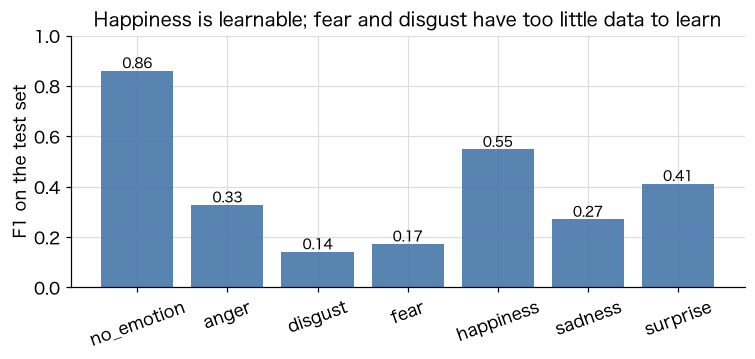

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(table.index, table["f1"], color=PALETTE[0], alpha=0.85)
for x, value in enumerate(table["f1"]):
    ax.text(x, value + 0.01, f"{value:.2f}", ha="center", fontsize=9)
ax.set_ylabel("F1 on the test set")
ax.set_ylim(0, 1)
ax.set_title("Happiness is learnable; fear and disgust have too little data to learn")
plt.xticks(rotation=20)
plt.tight_layout()

The pattern is stable across seeds: `happiness` (the one emotion with
five-digit support) and `no_emotion` are learned; `anger`, `sadness` and
`surprise` are partially learned; `fear` and `disgust` (a few hundred
utterances in the whole corpus) are close to unusable at the level of a
single utterance. Any downstream user of this classifier needs to know
that a per-utterance "fear" flag is not trustworthy.

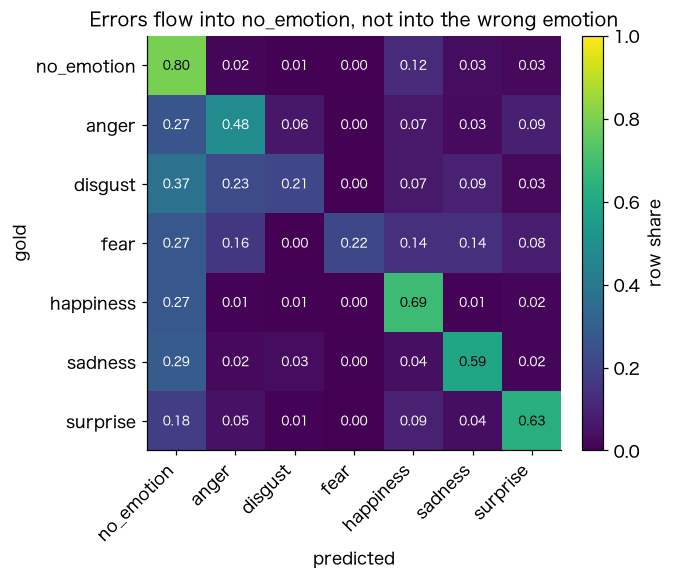

In [10]:
labels = list(range(len(EMOTIONS)))
confusion = pd.crosstab(
    pd.Series(test_y, name="gold"),
    pd.Series(predictions["tfidf_logreg"], name="predicted"),
).reindex(index=labels, columns=labels, fill_value=0)
row_norm = confusion.div(confusion.sum(axis=1).replace(0, 1), axis=0)

fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(row_norm.to_numpy(), cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(labels, EMOTIONS, rotation=45, ha="right")
ax.set_yticks(labels, EMOTIONS)
for i in labels:
    for j in labels:
        value = row_norm.iloc[i, j]
        ax.text(
            j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
            color="white" if value < 0.5 else "black",
        )
ax.set_xlabel("predicted")
ax.set_ylabel("gold")
ax.set_title("Errors flow into no_emotion, not into the wrong emotion")
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="row share")
plt.tight_layout()

The dominant error mode is an emotion being missed (predicted as
`no_emotion`), not confused with another emotion. For the valence
trajectories in notebook 03 this is the more benign failure: a missed
emotion pulls the valence estimate toward zero instead of flipping its
sign.

## Limitations

- DailyDialog is scripted English small talk written for language
  learners. Vocabulary, turn length and emotional register differ from
  real contact-center transcripts; the absolute F1 numbers do not
  transfer, only the methodology and the ranking logic do.
- Labels are single-annotator judgments on utterances out of a fixed set
  of seven classes; mixed or subtle emotions are forced into one label.
- One split, one seed, one model configuration. The margin over the
  lexicon baseline is large enough that the ranking is unlikely to flip,
  but no cross-validation variance is reported here.
- `no_emotion` absorbs both true neutrality and annotator uncertainty;
  treating it as a clean negative class overstates label quality.

## References

- Li, Su, Shen, Li, Cao, Niu. "DailyDialog: A Manually Labelled Multi-turn
  Dialogue Dataset." IJCNLP 2017.
- Pedregosa et al. "Scikit-learn: Machine Learning in Python." JMLR 2011.